---
#### 4-2. ML실습_다중분류(추가)
- Glass Type 
---

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings("ignore")

In [2]:
# data loading
train = pd.read_csv('data/glass-train.csv')
test = pd.read_csv('data/glass-test.csv')

print(train.shape, test.shape)
display(train.head())
display(test.head())

(149, 10) (65, 9)


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.51829,14.46,2.24,1.62,72.38,0.00,9.26,0.0,0.00,6
1,1.51610,13.33,3.53,1.34,72.67,0.56,8.33,0.0,0.00,3
2,1.52172,13.48,3.74,0.90,72.01,0.18,9.61,0.0,0.07,1
3,1.51905,13.60,3.62,1.11,72.64,0.14,8.76,0.0,0.00,1
4,1.51631,13.34,3.57,1.57,72.87,0.61,7.89,0.0,0.00,2


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.51748,12.86,3.56,1.27,73.21,0.54,8.38,0.00,0.17
1,1.52058,12.85,1.61,2.17,72.18,0.76,9.70,0.24,0.51
2,1.52475,11.45,0.00,1.88,72.19,0.81,13.24,0.00,0.34
3,1.51690,13.33,3.54,1.61,72.54,0.68,8.11,0.00,0.00
4,1.52177,13.75,1.01,1.36,72.19,0.33,11.14,0.00,0.00


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      149 non-null    float64
 1   Na      149 non-null    float64
 2   Mg      149 non-null    float64
 3   Al      149 non-null    float64
 4   Si      149 non-null    float64
 5   K       149 non-null    float64
 6   Ca      149 non-null    float64
 7   Ba      149 non-null    float64
 8   Fe      149 non-null    float64
 9   Type    149 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 11.8 KB


In [4]:
print(train.isnull().sum())
print(test.isnull().sum())

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64
RI    0
Na    0
Mg    0
Al    0
Si    0
K     0
Ca    0
Ba    0
Fe    0
dtype: int64


In [5]:
train['Type'].value_counts()

Type
2    53
1    49
7    23
3     9
5     8
6     7
Name: count, dtype: int64

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe'], dtype='object')


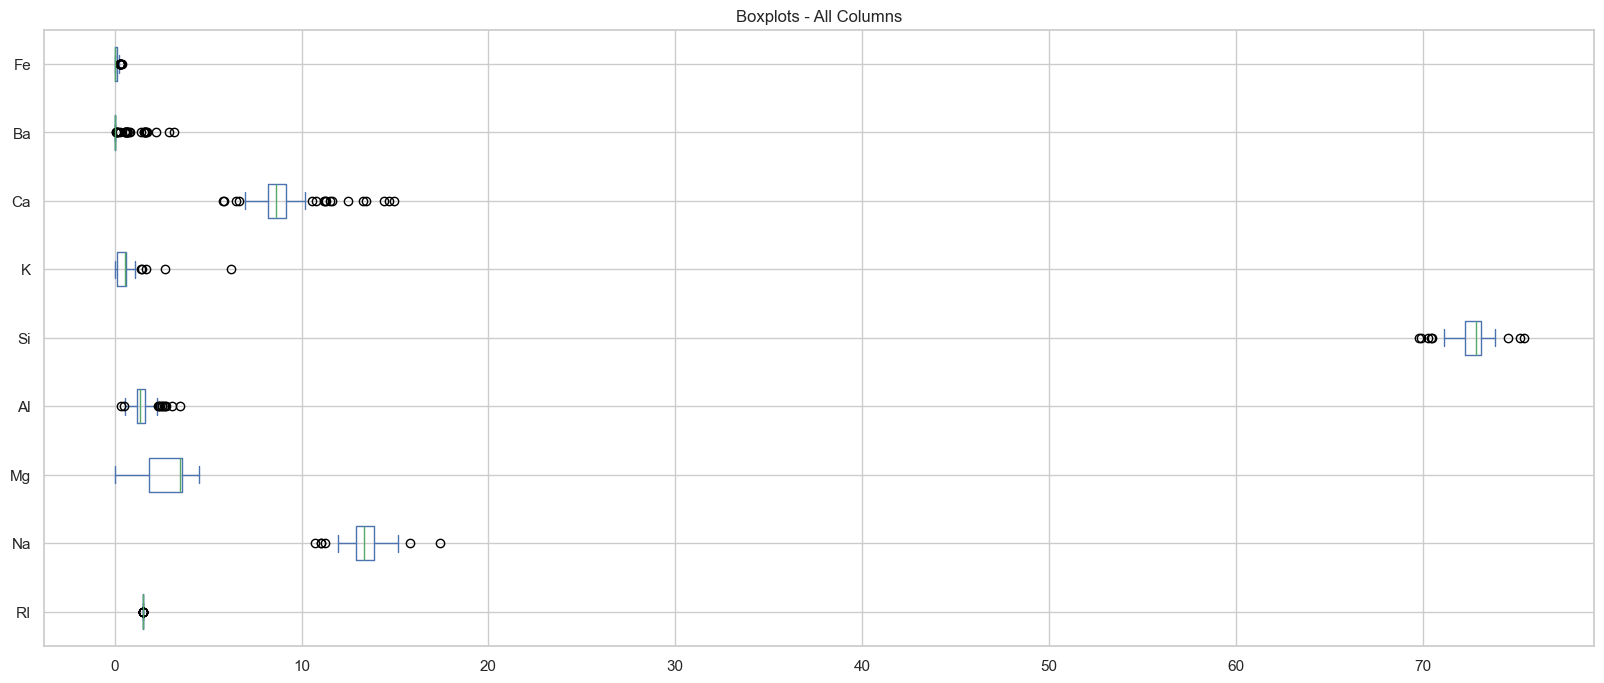

In [6]:
cols = train.columns[:-1]
print(cols)

train[cols].plot(kind='box', vert=False, grid=True, figsize=(20,8))
plt.title('Boxplots - All Columns')
plt.show()


- 결측치가 없고, 모두 수치형 변수
- 변수들의 단위가 상이하고 이상치가 상당히 포함되어 있음 
- -> 원-핫 인코딩 불필요, 트리모델을 사용하므로 스케일링과 이상치 제거 또한 불필요 

In [7]:
# target 분리 
y = train['Type']
X = train.drop('Type', axis=1)

# 검증데이터 분할 
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [10]:
# models 
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

########################################################################################
# 1. RandomForest 
########################################################################################
rf = RandomForestClassifier(random_state=120)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_valid)
rf_pred_proba = rf.predict_proba(X_valid)

acc = accuracy_score(y_valid, rf_pred)
f1 = f1_score(y_valid, rf_pred, average='macro')
roc = roc_auc_score(y_valid, rf_pred_proba, multi_class = 'ovr')

print('============= 1.RandomForest =======================')
print('Accuracy of RF = ', round(acc,4))
print('F1 of RF = ', round(f1,4))
print('ROC AUC of RF = ', round(roc,4))

########################################################################################
# 2. LightGBM
########################################################################################
lgb = LGBMClassifier(random_state=120, verbose=-1)
lgb.fit(X_train, y_train)

lgb_pred = lgb.predict(X_valid)
lgb_pred_proba = lgb.predict_proba(X_valid)

acc = accuracy_score(y_valid, lgb_pred)
f1 = f1_score(y_valid, lgb_pred, average='macro')
roc = roc_auc_score(y_valid, lgb_pred_proba, multi_class = 'ovr')

print('============= 2.LightGBM =======================')
print('Accuracy of LightGBM = ', round(acc,4))
print('F1 of LightGBM = ', round(f1,4))
print('ROC AUC of LightGBM = ', round(roc,4))

########################################################################################
# 3. XGBoost 
########################################################################################
# XGBoost는 y값이 연속적이어야 작동한다. 
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_valid_enc = le.transform(y_valid)

xgb = XGBClassifier(num_class=6, random_state=120)
#xgb = XGBClassifier(objective='multi:softprob', num_class=6, random_state=120)
xgb.fit(X_train, y_train_enc)

xgb_pred = xgb.predict(X_valid)
xgb_pred_proba = xgb.predict_proba(X_valid)

acc = accuracy_score(y_valid_enc, xgb_pred)
f1 = f1_score(y_valid_enc, xgb_pred, average='macro')
roc = roc_auc_score(y_valid_enc, xgb_pred_proba, multi_class='ovr')

print('============= 3.XGBClassifier =======================')
print('Accuracy of XGBoost =', round(acc,4))
print('F1 of XGBoost =', round(f1,4))
print('ROC AUC of XGBoost =', round(roc,4))

============= 1.RandomForest =======================
Accuracy of RF =  0.7667
F1 of RF =  0.5908
ROC AUC of RF =  0.868
============= 2.LightGBM =======================
Accuracy of LightGBM =  0.6
F1 of LightGBM =  0.5652
ROC AUC of LightGBM =  0.8794
============= 3.XGBClassifier =======================
Accuracy of XGBoost = 0.7333
F1 of XGBoost = 0.721
ROC AUC of XGBoost = 0.8862


In [12]:
# 최종모델(XGB)로 glass-test의 타겟값 예측
test_pred = xgb.predict(test)
print(test_pred)

test_new = test.copy()
test_new['Type'] = test_pred
test_new.head()

[0 1 1 1 3 1 5 0 5 0 0 0 4 0 2 0 0 5 1 0 1 3 1 3 0 1 0 0 1 5 3 1 1 3 0 0 2
 2 1 0 1 1 3 4 0 1 5 0 1 5 1 0 1 0 5 1 0 0 1 0 0 0 1 0 0]


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.51748,12.86,3.56,1.27,73.21,0.54,8.38,0.00,0.17,0
1,1.52058,12.85,1.61,2.17,72.18,0.76,9.70,0.24,0.51,1
2,1.52475,11.45,0.00,1.88,72.19,0.81,13.24,0.00,0.34,1
3,1.51690,13.33,3.54,1.61,72.54,0.68,8.11,0.00,0.00,1
4,1.52177,13.75,1.01,1.36,72.19,0.33,11.14,0.00,0.00,3


In [ ]:
train['Type'].value_counts()

KeyError: 'Tyep'